# Étape 2 — Résultats du DE séquentiel (Lounis, issues #6, #7, #8)

**Lecture seule : ce notebook ne fait aucun commit ni push.** Il récupère le code déjà sur GitHub, le compile, l'exécute et affiche les résultats à présenter.

Runtime : **CPU suffit** (pas besoin de GPU). Exécution → Tout exécuter. Durée : 3 à 5 minutes.

| Partie | Ce qu'on montre |
|---|---|
| 1 | Les 4 fonctions de `benchmarks.h` sont justes (comparaison NumPy, issue #6) |
| 2 | Un run du DE/rand/1/bin par fonction (issue #7) |
| 3 | Reproductibilité : même graine → même résultat |
| 4 | Critère de validation : 10 runs Sphere D=10, erreur < 1e-8 (issue #8) |
| 5 | Courbes de convergence (`--trace`) |
| 6 | Tableau de qualité et de temps : 4 fonctions × D = 10, 50, 100 |

### 0 — Récupérer le code (sans créer de branche)
🔑 Secrets → `GITHUB_TOKEN` doit être configuré, comme pour les notebooks précédents.

In [1]:
from google.colab import userdata
token = userdata.get("GITHUB_TOKEN")
!rm -rf /content/DE_CUDA
!git clone -q https://{token}@github.com/amenacer/DE_CUDA.git /content/DE_CUDA
%cd /content/DE_CUDA
# Version GitHub de la branche 2.7-2.9 (contient aussi 2.4-2.6), en lecture seule
!git checkout -q --detach origin/lounis/2.7-2.9-csv-convergence
# Fichiers de l'issue #6, pris sur leur branche, sans commit
!git show origin/lounis/2.3-tests-numpy:src/seq/test_vs_numpy.cpp > src/seq/test_vs_numpy.cpp
!git show origin/lounis/2.3-tests-numpy:scripts/verify_benchmarks_numpy.py > scripts/verify_benchmarks_numpy.py
!git log --oneline -3
!echo; lscpu | grep "Model name"

/content/DE_CUDA
342945a (HEAD, origin/lounis/2.7-2.9-csv-convergence) 2.7-2.9 : sortie CSV, --trace, controle de sante du DE sequentiel (refs #8)
99f40b3 (origin/lounis/2.4-2.6-de-sequentiel) 2.4-2.6 : DE/rand/1/bin sequentiel, CLI ./sde func D N seed (refs #7)
1fec54c (origin/amina/1.3-chronometrage) Merge pull request #24 from amenacer/amina/interface-commune

Model name:                              Intel(R) Xeon(R) CPU @ 2.20GHz


## 1 — Les 4 fonctions sont justes (issue #6)
Chaque fonction est recalculée en NumPy à partir de sa formule mathématique, sur 5 points aléatoires, et comparée au C++. Attendu : **`=== TOUS LES TESTS PASSENT ===`** (écart relatif < 1e-12).

In [2]:
%cd /content/DE_CUDA
!python3 scripts/verify_benchmarks_numpy.py

/content/DE_CUDA
  sphere     D= 10 pt=0  C++=105030.8235655  NumPy=105030.8235655  ecart_relatif=1.4e-16  OK
  sphere     D= 10 pt=1  C++=101768.981785645  NumPy=101768.981785645  ecart_relatif=0.0e+00  OK
  sphere     D= 10 pt=2  C++=101630.803159206  NumPy=101630.803159206  ecart_relatif=2.9e-16  OK
  sphere     D= 10 pt=3  C++=79442.3992754351  NumPy=79442.3992754351  ecart_relatif=0.0e+00  OK
  sphere     D= 10 pt=4  C++=53111.7303950159  NumPy=53111.7303950159  ecart_relatif=1.4e-16  OK
  rosenbrock D= 10 pt=0  C++=28294928881.0917  NumPy=28294928881.0917  ecart_relatif=0.0e+00  OK
  rosenbrock D= 10 pt=1  C++=51373625625.3218  NumPy=51373625625.3218  ecart_relatif=0.0e+00  OK
  rosenbrock D= 10 pt=2  C++=31520255641.9972  NumPy=31520255641.9972  ecart_relatif=0.0e+00  OK
  rosenbrock D= 10 pt=3  C++=41675604500.3475  NumPy=41675604500.3475  ecart_relatif=1.8e-16  OK
  rosenbrock D= 10 pt=4  C++=100042603848.451  NumPy=100042603848.451  ecart_relatif=0.0e+00  OK
  griewank   D= 1

## 2 — Un run du DE/rand/1/bin par fonction (issue #7)
D = 10, N = 50, graine 1, budget 10⁴ × D = 100 000 évaluations. F = 0,5, CR = 0,3 (valeurs de Qin et al.).
`best_error` = f(meilleur) − f(optimum) : 0 veut dire que l'optimum est trouvé.

In [3]:
%cd /content/DE_CUDA/src/seq
!g++ -std=c++14 -O2 -Wall -o sde sde.cpp && echo "compilation OK"
for f in ["sphere", "rosenbrock", "griewank", "rastrigin"]:
    !./sde {f} 10 50 1

/content/DE_CUDA/src/seq
compilation OK
func=sphere D=10 N=50 seed=1 best_error=0.000000000e+00 FE=100000 maxFE=100000 time_s=0.026053 sante=OK
func=rosenbrock D=10 N=50 seed=1 best_error=3.932151601e-02 FE=100000 maxFE=100000 time_s=0.026127 sante=OK
func=griewank D=10 N=50 seed=1 best_error=0.000000000e+00 FE=100000 maxFE=100000 time_s=0.042132 sante=OK
func=rastrigin D=10 N=50 seed=1 best_error=0.000000000e+00 FE=100000 maxFE=100000 time_s=0.037350 sante=OK


## 3 — Reproductibilité
Même graine → résultat **identique** au bit près. Graine différente → résultat différent (mais du même ordre).

In [4]:
%cd /content/DE_CUDA/src/seq
!./sde rosenbrock 10 50 7 | grep -o "best_error=[^ ]*"
!./sde rosenbrock 10 50 7 | grep -o "best_error=[^ ]*"
!./sde rosenbrock 10 50 8 | grep -o "best_error=[^ ]*"

/content/DE_CUDA/src/seq
best_error=8.610298119e-01
best_error=8.610298119e-01
best_error=2.677083333e+00


## 4 — Critère de validation de l'issue #8
10 runs Sphere, D = 10, N = 50 : chaque run doit avoir une erreur < 1e-8 et `sante=OK` (pas de NaN, population dans les bornes, budget respecté).

In [5]:
%cd /content/DE_CUDA
!python3 scripts/check_sde_sphere10.py

/content/DE_CUDA
[seed  1] best_error=0.000e+00  FE=100000  sante=OK  OK
[seed  2] best_error=0.000e+00  FE=100000  sante=OK  OK
[seed  3] best_error=0.000e+00  FE=100000  sante=OK  OK
[seed  4] best_error=0.000e+00  FE=100000  sante=OK  OK
[seed  5] best_error=0.000e+00  FE=100000  sante=OK  OK
[seed  6] best_error=0.000e+00  FE=100000  sante=OK  OK
[seed  7] best_error=0.000e+00  FE=100000  sante=OK  OK
[seed  8] best_error=0.000e+00  FE=100000  sante=OK  OK
[seed  9] best_error=0.000e+00  FE=100000  sante=OK  OK
[seed 10] best_error=0.000e+00  FE=100000  sante=OK  OK

=== TOUS LES RUNS PASSENT (erreur < 1e-8) ===
Resultats bruts : results/sde_sphere10_check.csv


## 5 — Courbes de convergence (`--trace`)
Erreur du meilleur individu à chaque génération, D = 30, N = 50, graine 1. Échelle logarithmique.
Une erreur exactement nulle est affichée à 1e-20 (le log de 0 n'existe pas).

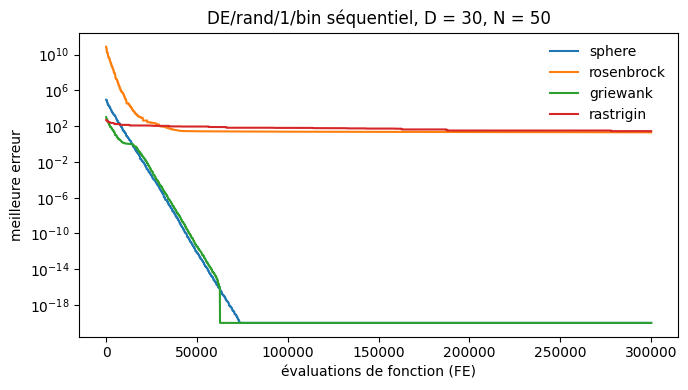

In [6]:
import subprocess, re, os
import matplotlib.pyplot as plt
SDE = "/content/DE_CUDA/src/seq/sde"
OUT = "/content/resultats_etape2"; os.makedirs(OUT, exist_ok=True)
TR = re.compile(r"TRACE gen=\d+ FE=(\d+) best_error=(\S+)")

fig, ax = plt.subplots(figsize=(7, 4))
for f in ["sphere", "rosenbrock", "griewank", "rastrigin"]:
    out = subprocess.run([SDE, f, "30", "50", "1", "--trace"], capture_output=True, text=True).stdout
    pts = [(int(a), max(float(b), 1e-20)) for a, b in TR.findall(out)]
    ax.semilogy([p[0] for p in pts], [p[1] for p in pts], label=f)
ax.set_xlabel("évaluations de fonction (FE)"); ax.set_ylabel("meilleure erreur")
ax.set_title("DE/rand/1/bin séquentiel, D = 30, N = 50")
ax.legend(frameon=False); fig.tight_layout()
fig.savefig(f"{OUT}/convergence_sde_D30.png", dpi=200); plt.show()

**À lire :** la courbe ne remonte jamais (la sélection ne garde un essai que s'il est au moins aussi bon). Sphere descend jusqu'à 0 ; Rosenbrock et Rastrigin stagnent plus haut : ce sont des fonctions plus difficiles (vallée étroite, nombreux minima locaux).

## 6 — Tableau de qualité et de temps
4 fonctions × D = 10, 50, 100, N = 100, 5 graines. Chaque run écrit une ligne dans le CSV commun de l'équipe.

In [7]:
import pandas as pd
CSV = f"{OUT}/sde_resultats.csv"
if os.path.exists(CSV): os.remove(CSV)
for f in ["sphere", "rosenbrock", "griewank", "rastrigin"]:
    for D in (10, 50, 100):
        for seed in range(1, 6):
            p = subprocess.run([SDE, f, str(D), "100", str(seed), CSV], capture_output=True, text=True)
            if "sante=OK" not in p.stdout:
                print("ANOMALIE :", p.stdout, p.stderr)
        print(f"{f:10s} D={D:3d} : 5 runs faits")

df = pd.read_csv(CSV)
tab = (df.groupby(["func", "D"])
         .agg(erreur_moy=("best_error", "mean"), erreur_ET=("best_error", "std"),
              erreur_mediane=("best_error", "median"), temps_moy_s=("time_s", "mean"), FE=("FE", "first"))
         .reindex(["sphere", "rosenbrock", "griewank", "rastrigin"], level=0))
pd.set_option("display.float_format", "{:.3e}".format)
display(tab)

sphere     D= 10 : 5 runs faits
sphere     D= 50 : 5 runs faits
sphere     D=100 : 5 runs faits
rosenbrock D= 10 : 5 runs faits
rosenbrock D= 50 : 5 runs faits
rosenbrock D=100 : 5 runs faits
griewank   D= 10 : 5 runs faits
griewank   D= 50 : 5 runs faits
griewank   D=100 : 5 runs faits
rastrigin  D= 10 : 5 runs faits
rastrigin  D= 50 : 5 runs faits
rastrigin  D=100 : 5 runs faits


erreur_moy  erreur_ET  erreur_mediane  temps_moy_s       FE
func       D                                                               
sphere     10    0.000e+00  0.000e+00       0.000e+00    2.556e-02   100000
           50    0.000e+00  0.000e+00       0.000e+00    5.281e-01   500000
           100   0.000e+00  0.000e+00       0.000e+00    2.246e+00  1000000
rosenbrock 10    1.493e+00  1.010e+00       8.751e-01    2.662e-02   100000
           50    4.088e+01  4.469e-01       4.099e+01    5.498e-01   500000
           100   8.974e+01  1.703e-01       8.980e+01    2.713e+00  1000000
griewank   10    0.000e+00  0.000e+00       0.000e+00    4.637e-02   100000
           50    0.000e+00  0.000e+00       0.000e+00    1.097e+00   500000
           100   0.000e+00  0.000e+00       0.000e+00    3.709e+00  1000000
rastrigin  10    0.000e+00  0.000e+00       0.000e+00    3.971e-02   100000
           50    1.693e+02  7.454e+00       1.707e+02    1.308e+00   500000
           100   5.364e+02  1.104e+01       5.372e+02    5.403e+00  1000000

**À lire :**
- `FE` = 10⁴ × D exactement : le budget du sujet est respecté.
- Le temps croît à peu près comme D² (D fois plus d'évaluations, chacune D fois plus longue) : c'est ce coût que le GPU doit réduire.
- Ce CSV a le même format que celui du GPU d'Amina (`algo, func, D, N, seed, best_error, time_s, FE`), donc il se compare directement.

### 7 — Télécharger les résultats (aucun push)

In [8]:
!ls -la /content/resultats_etape2
from google.colab import files
files.download(f"{OUT}/convergence_sde_D30.png")
files.download(f"{OUT}/sde_resultats.csv")

total 92
drwxr-xr-x 2 root root  4096 Oct  7 12:35 .
drwxr-xr-x 1 root root  4096 Oct  7 12:35 ..
-rw-r--r-- 1 root root 78911 Oct  7 12:35 convergence_sde_D30.png
-rw-r--r-- 1 root root  3155 Oct  7 12:37 sde_resultats.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>